# San Diego Parking Slot Availability Prediction
**Source:** City of San Diego Open Data Portal  
**Dataset 1:** Parking Meter Transactions 2020 — 1,953,052 rows  
**Dataset 2:** Parking Meter Locations Active — 4,060 rows  
**Task:** Predict whether a parking slot will be a Long Stay (>60 mins) or Short Stay  
**Models:** Random Forest vs XGBoost  

---

## Problem Statement
Drivers waste time searching for available parking in San Diego.  
Using historical transaction data from smart parking meters, we predict  
whether a parking slot will be occupied for more than 60 minutes —  
helping drivers and city planners understand slot turnover and availability.

---

# PART 1: PREPROCESSING

Everything done to the raw data before it goes into the model —
loading, cleaning, joining, feature engineering, encoding, and splitting.
---

# Load and Explore Raw Data
---

##  Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, precision_score,
    recall_score, f1_score
)
from xgboost import XGBClassifier

print('All libraries loaded successfully.')

All libraries loaded successfully.


##  Load Datasets

In [15]:
# Load Parking Meter Locations (Active)
locations = pd.read_csv('parking_meters_current.csv')

print(f'Locations loaded.')
print(f'Rows    : {locations.shape[0]:,}')
print(f'Columns : {locations.shape[1]}')
locations.head()

Locations loaded.
Rows    : 4,060
Columns : 16


,zone,area,sub-area,pole,latitude,longitude,configid,configname,time_start,time_end,time_limit,days_in_operation,price,mobile_pay,multi_space,restrictions
0,Spares,Spares,Spares,Spares (San Diego CA),32.715329,-117.157255,63,San Diego Default,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Downtown,Core - Columbia,1000 SECOND AVE,2-1014,32.716327,-117.162596,57001,"Downtown MK5 – 30 Min Max $2.50 HR, 8am-8pm, M...",8am,8pm,30 min,Mon-Sat,$2.50 HR,NaN,NaN,NaN
2,Downtown,Core - Columbia,1000 SECOND AVE,2-1016,32.716370,-117.162933,57001,"Downtown MK5 – 30 Min Max $2.50 HR, 8am-8pm, M...",8am,8pm,30 min,Mon-Sat,$2.50 HR,NaN,NaN,NaN
3,Downtown,Core - Columbia,1000 SECOND AVE,2-1018,32.716393,-117.162453,57001,"Downtown MK5 – 30 Min Max $2.50 HR, 8am-8pm, M...",8am,8pm,30 min,Mon-Sat,$2.50 HR,NaN,NaN,NaN
4,Downtown,Core - Columbia,100 A ST,A-106,32.718846,-117.163056,57004,"Downtown MK5 - 2 Hour Max $2.50 HR, 8am-8pm, M...",8am,8pm,2 hour,Mon-Sat,$2.50 HR,NaN,NaN,NaN


In [3]:
# Load Parking Meter Transactions 2020
# Source: https://seshat.datasd.org/parking_meters_transactions/treas_parking_payments_2020_datasd.csv
transactions = pd.read_csv('treas_parking_payments_2020_datasd.csv')

print(f'Transactions loaded.')
print(f'Rows    : {transactions.shape[0]:,}')
print(f'Columns : {transactions.shape[1]}')
transactions.head()

Transactions loaded.
Rows    : 1,953,052
Columns : 6


,pole_id,meter_type,date_trans_start,date_meter_expire,trans_amt,pay_method
0,IV-424,SS,2020-02-24 11:39:31,2020-02-24 13:39:31,250,CREDIT CARD
1,IV-424,SS,2020-02-24 13:24:46,2020-02-24 15:24:46,225,CREDIT CARD
2,IV-424,SS,2020-02-24 15:25:52,2020-02-24 17:25:52,250,CREDIT CARD
3,NU-100,SS,2020-03-14 17:08:35,2020-03-14 17:56:35,100,CASH
4,NU-100,SS,2020-03-14 17:09:24,2020-03-14 18:00:00,25,CASH


##  Explore Locations

In [4]:
print('Columns:', list(locations.columns))
print('\nData types:')
print(locations.dtypes)
print('\nMissing values:')
print(locations.isnull().sum())

Columns: ['zone', 'area', 'sub-area', 'pole', 'latitude', 'longitude', 'configid', 'configname', 'time_start', 'time_end', 'time_limit', 'days_in_operation', 'price', 'mobile_pay', 'multi_space', 'restrictions']

Data types:
zone                  object
area                  object
sub-area              object
pole                  object
latitude             float64
longitude            float64
configid               int64
configname            object
time_start            object
time_end              object
time_limit            object
days_in_operation     object
price                 object
mobile_pay            object
multi_space           object
restrictions          object
dtype: object

Missing values:
zone                    0
area                    0
sub-area                0
pole                    0
latitude                0
longitude               0
configid                0
configname              0
time_start             42
time_end               42
time_limit          

In [5]:
print('Meters per zone:')
print(locations['zone'].value_counts())
print(f'\nUnique areas  : {locations["area"].nunique()}')
print(f'Unique meters : {locations["pole"].nunique()}')

Meters per zone:
zone
Downtown         2404
Uptown           1090
Mid-City          348
City               90
Balboa Park        60
Pacific Beach      29
San Ysidro         25
Test Zone          13
Spares              1
Name: count, dtype: int64

Unique areas  : 42
Unique meters : 4060


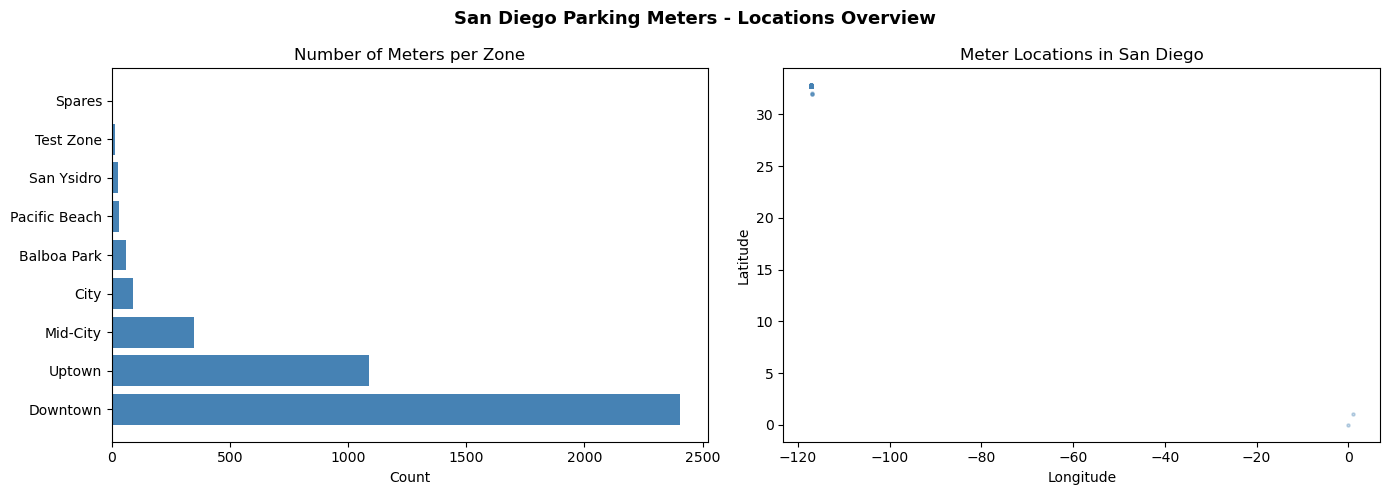

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('San Diego Parking Meters - Locations Overview', fontsize=13, fontweight='bold')

zone_counts = locations['zone'].value_counts()
axes[0].barh(zone_counts.index, zone_counts.values, color='steelblue')
axes[0].set_title('Number of Meters per Zone')
axes[0].set_xlabel('Count')

axes[1].scatter(locations['longitude'], locations['latitude'],
                alpha=0.3, s=5, c='steelblue')
axes[1].set_title('Meter Locations in San Diego')
axes[1].set_xlabel('Longitude')
axes[1].set_ylabel('Latitude')

plt.tight_layout()
plt.show()

##  Explore Transactions

In [10]:
print('Columns:', list(transactions.columns))
print('\nData types:')
print(transactions.dtypes)
print('\nMissing values:')
print(transactions.isnull().sum())

Columns: ['pole_id', 'meter_type', 'date_trans_start', 'date_meter_expire', 'trans_amt', 'pay_method']

Data types:
pole_id                      object
meter_type                   object
date_trans_start     datetime64[ns]
date_meter_expire    datetime64[ns]
trans_amt                     int64
pay_method                   object
dtype: object

Missing values:
pole_id              0
meter_type           0
date_trans_start     0
date_meter_expire    0
trans_amt            0
pay_method           0
dtype: int64


In [12]:
transactions['date_trans_start']  = pd.to_datetime(transactions['date_trans_start'])
transactions['date_meter_expire'] = pd.to_datetime(transactions['date_meter_expire'])

print(f'Date range:')
print(f'  From : {transactions["date_trans_start"].min()}')
print(f'  To   : {transactions["date_trans_start"].max()}')
print(f'\nUnique meters : {transactions["pole_id"].nunique():,}')
print(f'Total records : {len(transactions):,}')
print(f'\nPayment methods:')
print(transactions['pay_method'].value_counts())

Date range:
  From : 2020-02-24 11:39:31
  To   : 2020-12-31 23:46:03

Unique meters : 4,592
Total records : 1,953,052

Payment methods:
pay_method
CASH           1058818
CREDIT CARD     892069
SMART CARD        2165
Name: count, dtype: int64


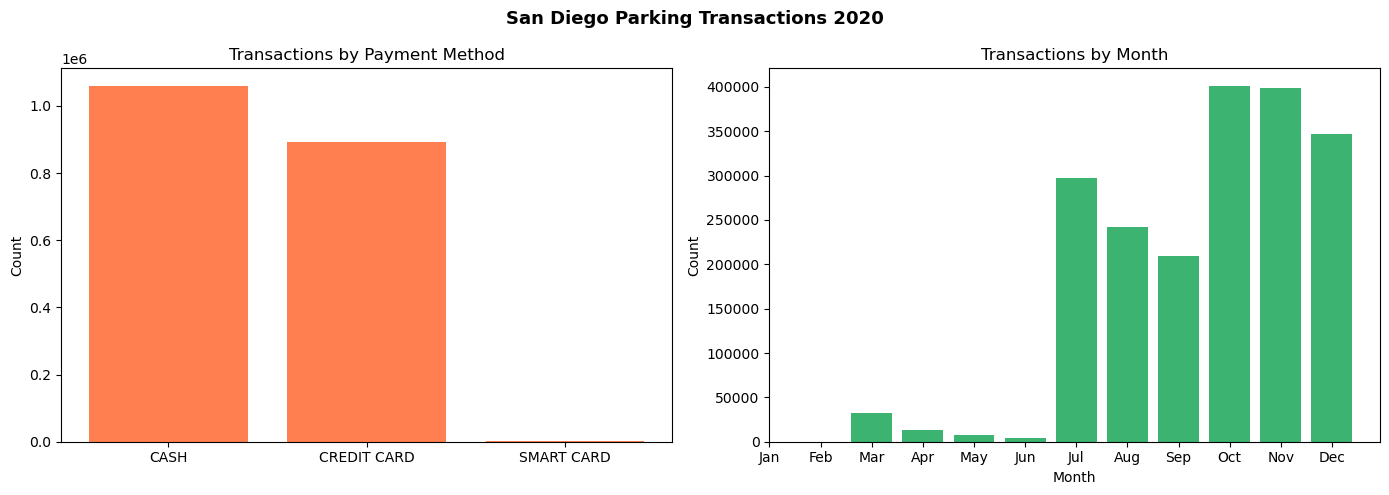

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('San Diego Parking Transactions 2020', fontsize=13, fontweight='bold')

pay_counts = transactions['pay_method'].value_counts()
axes[0].bar(pay_counts.index, pay_counts.values, color='coral')
axes[0].set_title('Transactions by Payment Method')
axes[0].set_ylabel('Count')

monthly = transactions['date_trans_start'].dt.month.value_counts().sort_index()
axes[1].bar(monthly.index, monthly.values, color='mediumseagreen')
axes[1].set_title('Transactions by Month')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Count')
axes[1].set_xticks(range(1,13))
axes[1].set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun',
                          'Jul','Aug','Sep','Oct','Nov','Dec'])
plt.tight_layout()
plt.show()

##  Check Join Key

In [16]:
trans_poles  = set(transactions['pole_id'].unique())
loc_poles    = set(locations['pole'].unique())
common_poles = trans_poles.intersection(loc_poles)

print(f'Meters in transactions : {len(trans_poles):,}')
print(f'Meters in locations    : {len(loc_poles):,}')
print(f'Common meters (join)   : {len(common_poles):,}')
print(f'\nJoin key: pole_id (transactions) = pole (locations)')

Meters in transactions : 4,592
Meters in locations    : 4,060
Common meters (join)   : 3,334

Join key: pole_id (transactions) = pole (locations)


#  Data Cleaning

## Step 6: Clean Transactions

In [17]:
# Rename join key to match locations
transactions = transactions.rename(columns={'pole_id': 'pole'})

# Remove duplicates
before = len(transactions)
transactions = transactions.drop_duplicates()
print(f'Duplicates removed : {before - len(transactions):,}')

# Remove rows where expire is before start (invalid)
invalid = transactions[transactions['date_meter_expire'] < transactions['date_trans_start']]
print(f'Invalid rows (expire < start) : {len(invalid):,}')
transactions = transactions[transactions['date_meter_expire'] >= transactions['date_trans_start']]

# Remove zero-duration rows — payment recorded but no time added (data error)
duration_check = (transactions['date_meter_expire'] - transactions['date_trans_start']).dt.total_seconds() / 60
zero_duration = (duration_check == 0).sum()
print(f'Zero-duration rows (payment but 0 mins) : {zero_duration:,}')
transactions = transactions[duration_check > 0]

print(f'\nClean transactions : {len(transactions):,}')

Duplicates removed : 12
Invalid rows (expire < start) : 0
Zero-duration rows (payment but 0 mins) : 44,806

Clean transactions : 1,908,234


##  Clean Locations

In [18]:
# Keep only relevant columns
location_cols = ['pole','zone','area','sub-area','latitude','longitude',
                 'time_limit','days_in_operation','price']
locations = locations[location_cols].copy()

# Remove Spares and Test Zone — not real meters
locations = locations[~locations['zone'].isin(['Spares', 'Test Zone'])]

# Remove rows with invalid coordinates (0,0 dummy entries)
locations = locations[(locations['latitude'].abs() > 1) & (locations['longitude'].abs() > 1)]

# Fill missing values
locations['time_limit']        = locations['time_limit'].fillna('Unknown')
locations['days_in_operation'] = locations['days_in_operation'].fillna('Unknown')
locations['price']             = locations['price'].fillna('Unknown')

print(f'Clean locations : {len(locations):,}')
print(f'Missing values  :\n{locations.isnull().sum()}')

Clean locations : 4,045
Missing values  :
pole                 0
zone                 0
area                 0
sub-area             0
latitude             0
longitude            0
time_limit           0
days_in_operation    0
price                0
dtype: int64


## Step 8: Join Datasets

In [20]:
# Inner join on pole — keeps only meters that exist in both datasets
df = transactions.merge(locations, on='pole', how='inner')

print(f'Merged shape : {df.shape}')
print(f'Columns      : {list(df.columns)}')
df.head()

Merged shape : (1474238, 14)
Columns      : ['pole', 'meter_type', 'date_trans_start', 'date_meter_expire', 'trans_amt', 'pay_method', 'zone', 'area', 'sub-area', 'latitude', 'longitude', 'time_limit', 'days_in_operation', 'price']


,pole,meter_type,date_trans_start,date_meter_expire,trans_amt,pay_method,zone,area,sub-area,latitude,longitude,time_limit,days_in_operation,price
0,IV-424,SS,2020-02-24 11:39:31,2020-02-24 13:39:31,250,CREDIT CARD,Uptown,Bankers Hill,400 IVY ST,32.728334,-117.160658,2 hour,Mon-Sat,$2.50 HR
1,IV-424,SS,2020-02-24 13:24:46,2020-02-24 15:24:46,225,CREDIT CARD,Uptown,Bankers Hill,400 IVY ST,32.728334,-117.160658,2 hour,Mon-Sat,$2.50 HR
2,IV-424,SS,2020-02-24 15:25:52,2020-02-24 17:25:52,250,CREDIT CARD,Uptown,Bankers Hill,400 IVY ST,32.728334,-117.160658,2 hour,Mon-Sat,$2.50 HR
3,WAH-200N,SS,2020-03-16 09:02:46,2020-03-16 11:02:46,250,CREDIT CARD,Downtown,Little Italy,200 WEST ASH ST,32.719903,-117.165766,2 hour,Mon-Sat,$2.50 HR
4,WAH-200N,SS,2020-03-16 09:11:01,2020-03-16 10:11:02,125,CREDIT CARD,Downtown,Little Italy,200 WEST ASH ST,32.719903,-117.165766,2 hour,Mon-Sat,$2.50 HR
